# 🚦 Traffic Accident Hotspot Analyzer
## Notebook 03 — Risk Prediction

**Input:** `../data/accidents_clustered.parquet` (from 02_clustering.ipynb)

**Goal:** Train a model that predicts **High / Medium / Low** accident risk given:
- Location (lat, lon)
- Time (hour, day of week)
- Weather conditions

### What we cover:
1. Load data & define target variable
2. Feature engineering for ML
3. Train/test split + class balancing
4. Baseline model — Logistic Regression
5. Upgraded model — Random Forest
6. Model evaluation (confusion matrix, ROC, feature importance)
7. Prediction function — input any location + time → Risk Level
8. Save model artifacts for Django

---
## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import os
import warnings

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d', '#e9c46a']
sns.set_palette(PALETTE)

# ── Paths ────────────────────────────────────────────────────────────────────
INPUT_PATH  = '/kaggle/input/datasets/prateekagrahari/clustered/accidents_clustered.parquet'
import os
OUTPUT_DIR = '/kaggle/working/data/'
MODEL_DIR    = '/kaggle/working/models/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
print('✅ Imports done')

✅ Imports done


---
## 2. Load Data & Define Target

In [2]:
df = pd.read_parquet(INPUT_PATH)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

Loaded: 710,467 rows, 33 columns
Columns: ['ID', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'City', 'County', 'State', 'Zipcode', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Crossing', 'Junction', 'Traffic_Signal', 'Sunrise_Sunset', 'Hour', 'DayOfWeek', 'Month', 'MonthName', 'Year', 'IsWeekend', 'Duration_min', 'Season', 'TimeOfDay', 'WeatherGroup', 'Cluster', 'Risk', 'Cluster_Mean_Severity']


In [3]:
# ── Build Risk target from Severity ──────────────────────────────────────────
# Notebook 02 assigned Risk only to top-city clustered rows.
# Here we build Risk for the ENTIRE dataset from Severity so
# we have maximum training data.
#
# Mapping:
#   Severity 1       → Low
#   Severity 2       → Medium
#   Severity 3 or 4  → High

def severity_to_risk(sev):
    if sev <= 1:   return 'Low'
    elif sev == 2: return 'Medium'
    else:          return 'High'

df['Risk_Label'] = df['Severity'].apply(severity_to_risk)

print('Risk_Label distribution:')
print(df['Risk_Label'].value_counts())
print()
print('Class balance (%):')
print((df['Risk_Label'].value_counts(normalize=True) * 100).round(1))

Risk_Label distribution:
Risk_Label
Medium    580856
High      125038
Low         4573
Name: count, dtype: int64

Class balance (%):
Risk_Label
Medium    81.8
High      17.6
Low        0.6
Name: proportion, dtype: float64


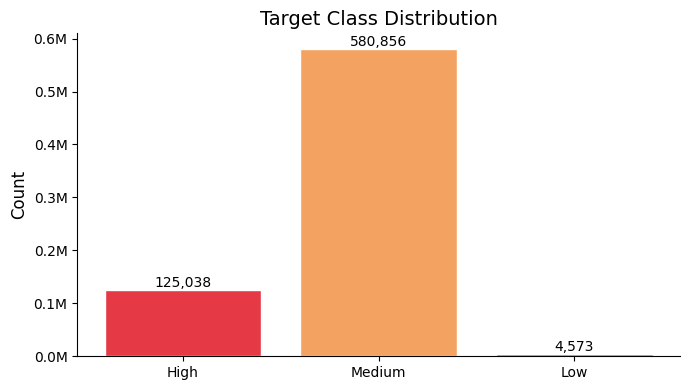

In [4]:
# ── Visualise class balance ───────────────────────────────────────────────────
risk_counts = df['Risk_Label'].value_counts().reindex(['High','Medium','Low'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(risk_counts.index, risk_counts.values,
       color=['#e63946', '#f4a261', '#2a9d8f'], edgecolor='white')
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering for ML

In [5]:
# ── Select & encode features ──────────────────────────────────────────────────

FEATURE_COLS = [
    # Location
    'Start_Lat', 'Start_Lng',
    # Time
    'Hour', 'Month',
    # Weather numerics
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)',
    # Categorical (will be encoded)
    'WeatherGroup', 'Sunrise_Sunset', 'Season', 'TimeOfDay',
    # Infrastructure
    'Junction', 'Traffic_Signal', 'Crossing',
    # Weekend flag
    'IsWeekend',
]

TARGET_COL = 'Risk_Label'

# Keep only rows where all feature cols are present
df_ml = df[FEATURE_COLS + [TARGET_COL]].dropna()
print(f'ML dataset size: {len(df_ml):,}')

ML dataset size: 710,467


In [6]:
# ── Cyclical encoding for Hour and Month ──────────────────────────────────────
# Raw numeric hour (0–23) is misleading for ML:
# hour 23 and hour 0 are 1 apart but numerically 23 apart.
# Encode as sin/cos to preserve circular continuity.

df_ml = df_ml.copy()
df_ml['Hour_sin']   = np.sin(2 * np.pi * df_ml['Hour']  / 24)
df_ml['Hour_cos']   = np.cos(2 * np.pi * df_ml['Hour']  / 24)
df_ml['Month_sin']  = np.sin(2 * np.pi * df_ml['Month'] / 12)
df_ml['Month_cos']  = np.cos(2 * np.pi * df_ml['Month'] / 12)

# Drop raw hour/month — replaced by cyclical versions
df_ml.drop(columns=['Hour', 'Month'], inplace=True)

print('✅ Cyclical encoding done')

✅ Cyclical encoding done


In [7]:
# ── One-hot encode categoricals ───────────────────────────────────────────────
CAT_COLS = ['WeatherGroup', 'Sunrise_Sunset', 'Season', 'TimeOfDay']

df_ml = pd.get_dummies(df_ml, columns=CAT_COLS, drop_first=False)

# ── Boolean → int ────────────────────────────────────────────────────────────
bool_cols = df_ml.select_dtypes('bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

print(f'Feature matrix shape after encoding: {df_ml.shape}')
print(f'Features: {[c for c in df_ml.columns if c != TARGET_COL]}')

Feature matrix shape after encoding: (710467, 33)
Features: ['Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Junction', 'Traffic_Signal', 'Crossing', 'IsWeekend', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'WeatherGroup_Clear', 'WeatherGroup_Cloudy', 'WeatherGroup_Fog/Mist', 'WeatherGroup_Other', 'WeatherGroup_Rain', 'WeatherGroup_Snow/Ice', 'WeatherGroup_Thunderstorm', 'Sunrise_Sunset_Day', 'Sunrise_Sunset_Night', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'TimeOfDay_Afternoon', 'TimeOfDay_Evening', 'TimeOfDay_Morning', 'TimeOfDay_Night']


In [8]:
# ── Encode target labels ───────────────────────────────────────────────────────
RISK_ORDER = ['Low', 'Medium', 'High']    # ordinal order
le = LabelEncoder()
le.fit(RISK_ORDER)
df_ml['Risk_Encoded'] = le.transform(df_ml[TARGET_COL])

# Final X, y
FEATURES = [c for c in df_ml.columns if c not in [TARGET_COL, 'Risk_Encoded']]
X = df_ml[FEATURES].values.astype(np.float32)
y = df_ml['Risk_Encoded'].values

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Classes : {le.classes_}  (encoded as {list(range(len(le.classes_)))})')

X shape : (710467, 32)
y shape : (710467,)
Classes : ['High' 'Low' 'Medium']  (encoded as [0, 1, 2])


---
## 4. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class balance in both splits
)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print()

# Class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
cw_dict = {i: w for i, w in enumerate(class_weights)}
print(f'Class weights: {cw_dict}')

Train size : 568,373
Test size  : 142,094

Class weights: {0: np.float64(1.8940084641274284), 1: np.float64(51.77853694087638), 2: np.float64(0.40771291171347984)}


---
## 5. Baseline — Logistic Regression

In [10]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   multi_class='multinomial',
                   solver='lbfgs',
                   max_iter=300,
                   class_weight='balanced',
                   random_state=RANDOM_STATE
               ))
])

print('Training Logistic Regression...')
lr_pipeline.fit(X_train, y_train)

lr_preds = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)

print('\n── Classification Report ──────────────────────────────')
print(classification_report(y_test, lr_preds,
                             target_names=le.classes_))

lr_auc = roc_auc_score(y_test, lr_proba, multi_class='ovr', average='macro')
print(f'Macro ROC-AUC: {lr_auc:.4f}')

Training Logistic Regression...

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

        High       0.27      0.63      0.38     25008
         Low       0.03      0.83      0.06       914
      Medium       0.90      0.47      0.62    116172

    accuracy                           0.50    142094
   macro avg       0.40      0.64      0.35    142094
weighted avg       0.78      0.50      0.57    142094

Macro ROC-AUC: 0.7392


---
## 6. Main Model — Random Forest

In [11]:
# Random Forest — no scaling needed, handles mixed feature types well
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Training Random Forest (this may take ~2 min on 3M rows)...')
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

print('\n── Classification Report ──────────────────────────────')
print(classification_report(y_test, rf_preds,
                             target_names=le.classes_))

rf_auc = roc_auc_score(y_test, rf_proba, multi_class='ovr', average='macro')
print(f'Macro ROC-AUC: {rf_auc:.4f}')

Training Random Forest (this may take ~2 min on 3M rows)...

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

        High       0.36      0.77      0.49     25008
         Low       0.07      0.79      0.12       914
      Medium       0.94      0.63      0.75    116172

    accuracy                           0.65    142094
   macro avg       0.45      0.73      0.45    142094
weighted avg       0.83      0.65      0.70    142094

Macro ROC-AUC: 0.8450


---
## 7. Model Evaluation

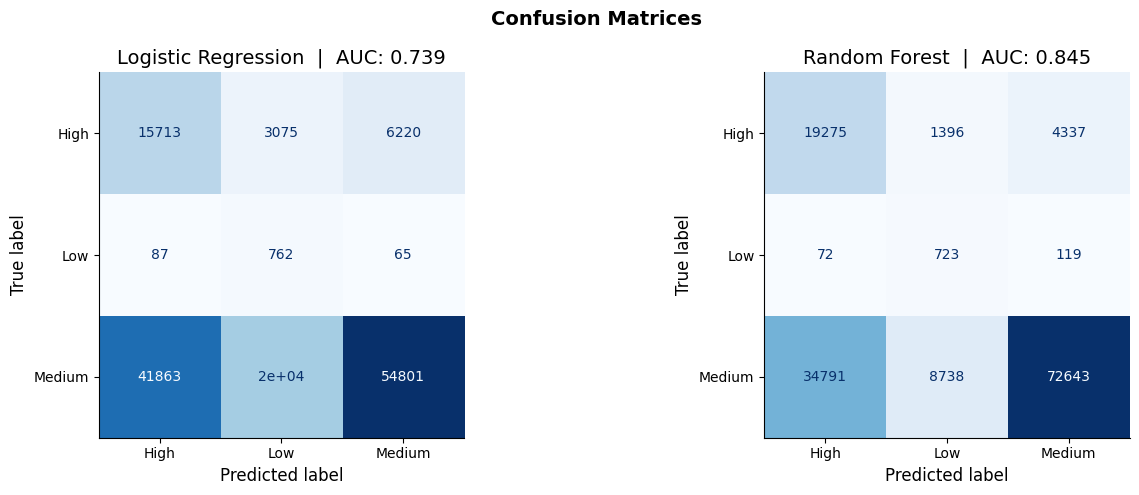

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    
    # Evaluate which AUC to use first
    current_auc = lr_auc if title == 'Logistic Regression' else rf_auc
    ax.set_title(f'{title}\nROC-AUC: {current_auc:.3f}')

# Fix title display (Note: see section below)
axes[0].set_title(f'Logistic Regression  |  AUC: {lr_auc:.3f}')
axes[1].set_title(f'Random Forest  |  AUC: {rf_auc:.3f}')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

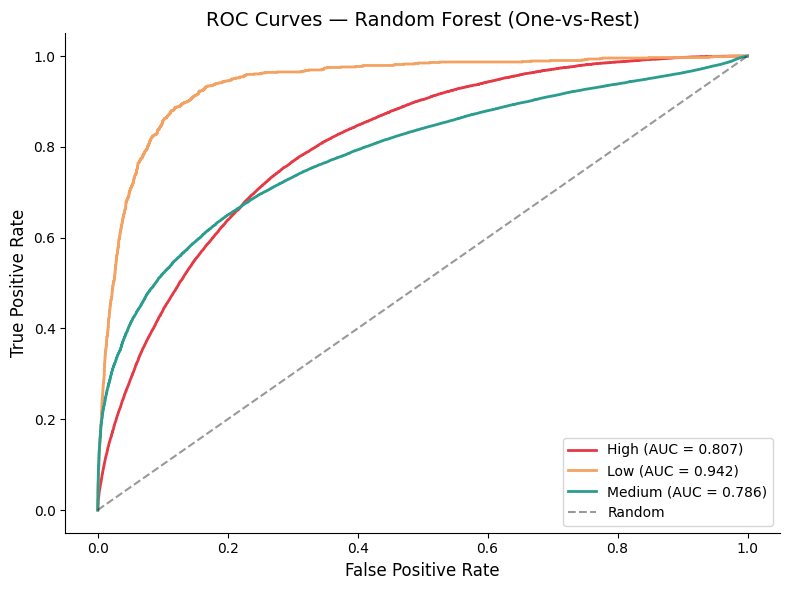

In [14]:
# ── 7.2 ROC curves (One-vs-Rest, Random Forest) ───────────────────────────────
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#e63946', '#f4a261', '#2a9d8f']

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    auc_val     = roc_auc_score(y_test_bin[:, i], rf_proba[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Random Forest (One-vs-Rest)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

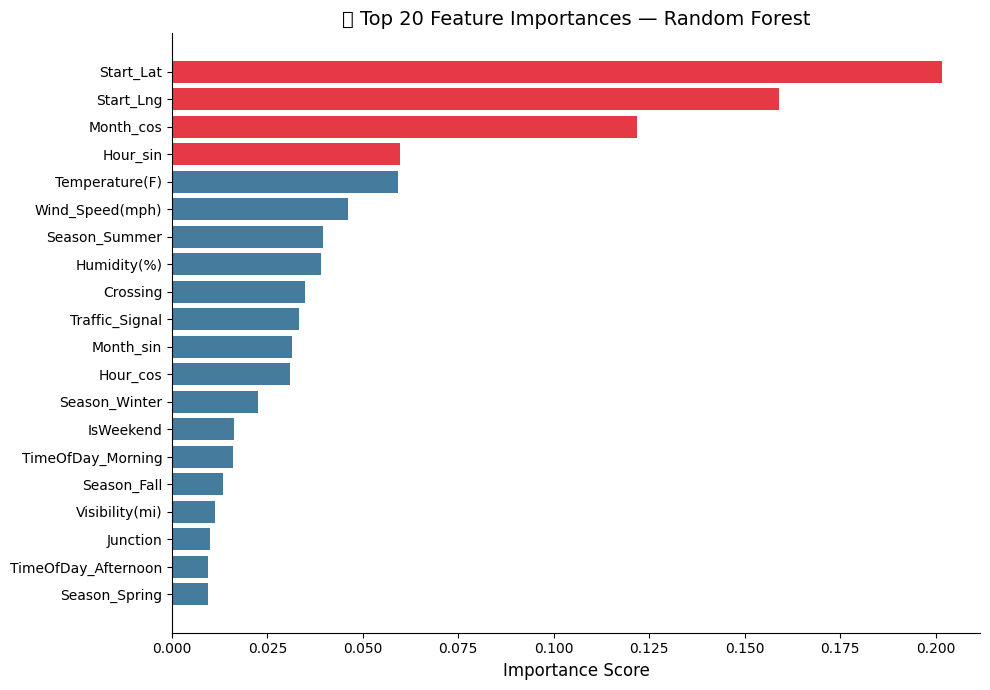

Top 10 features:
Start_Lat          0.201570
Start_Lng          0.158909
Month_cos          0.121692
Hour_sin           0.059828
Temperature(F)     0.059236
Wind_Speed(mph)    0.045989
Season_Summer      0.039562
Humidity(%)        0.039019
Crossing           0.034766
Traffic_Signal     0.033191


In [15]:
# ── 7.3 Feature Importance ────────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
top_feat    = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#e63946' if v >= top_feat.quantile(0.8)
           else '#457b9d' for v in top_feat.values]
ax.barh(top_feat.index, top_feat.values, color=colors)
ax.set_title('🔍 Top 20 Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.nlargest(10).to_string())

In [16]:
# ── 7.4 Cross-validation (5-fold) on Random Forest ───────────────────────────
# Use a smaller sample for CV to keep it fast
CV_SAMPLE = 100_000
idx       = np.random.choice(len(X_train), size=CV_SAMPLE, replace=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    rf_model, X_train[idx], y_train[idx],
    cv=cv, scoring='f1_macro', n_jobs=-1
)

print(f'Cross-val F1 (macro): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold scores     : {[round(s, 4) for s in cv_scores]}')

Cross-val F1 (macro): 0.4667 ± 0.0038
Per-fold scores     : [np.float64(0.4632), np.float64(0.4666), np.float64(0.4707), np.float64(0.4618), np.float64(0.4711)]


              Model  Accuracy  F1 Macro  ROC-AUC
Logistic Regression    0.5016    0.3538   0.7392
      Random Forest    0.6520    0.4539   0.8450


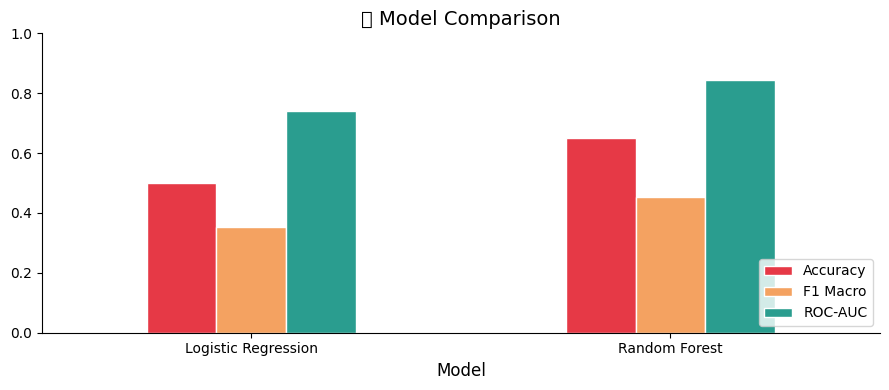

In [17]:
# ── 7.5 Model comparison summary ─────────────────────────────────────────────
from sklearn.metrics import f1_score, accuracy_score

results = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds)
    ],
    'F1 Macro': [
        f1_score(y_test, lr_preds, average='macro'),
        f1_score(y_test, rf_preds, average='macro')
    ],
    'ROC-AUC' : [lr_auc, rf_auc]
}).round(4)

print(results.to_string(index=False))

# Visual
ax = results.set_index('Model')[['Accuracy','F1 Macro','ROC-AUC']].plot(
    kind='bar', figsize=(9, 4), color=PALETTE[:3], edgecolor='white'
)
ax.set_title('📊 Model Comparison')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Prediction Function

This is what the Django "Check Risk" tool will call.

In [18]:
# Store the exact feature list and dummy column names so the predictor
# can rebuild the same one-hot layout at inference time
FEATURE_META = {
    'features'        : FEATURES,
    'weather_groups'  : df['WeatherGroup'].unique().tolist(),
    'seasons'         : ['Winter', 'Spring', 'Summer', 'Fall'],
    'time_of_day'     : ['Morning', 'Afternoon', 'Evening', 'Night'],
    'sunrise_sunset'  : ['Day', 'Night'],
    'risk_classes'    : le.classes_.tolist(),
}


def build_input_vector(lat, lon, hour, month,
                       temperature_f=65.0,
                       humidity_pct=50.0,
                       visibility_mi=10.0,
                       wind_speed_mph=5.0,
                       precipitation_in=0.0,
                       weather_group='Clear',
                       junction=False,
                       traffic_signal=False,
                       crossing=False):
    """
    Build a single-row feature DataFrame matching the training schema.

    All parameters except lat/lon/hour/month have sensible defaults
    so the Django form only needs to collect the essentials.
    """

    # Derived features
    def get_season(m):
        if m in [12,1,2]: return 'Winter'
        if m in [3,4,5]:  return 'Spring'
        if m in [6,7,8]:  return 'Summer'
        return 'Fall'

    def get_time_of_day(h):
        if 5  <= h < 12: return 'Morning'
        if 12 <= h < 17: return 'Afternoon'
        if 17 <= h < 21: return 'Evening'
        return 'Night'

    is_weekend    = 0   # conservative default
    sunrise_sunset = 'Day' if 6 <= hour < 20 else 'Night'
    season        = get_season(month)
    time_of_day   = get_time_of_day(hour)

    # Base numerics
    row = {
        'Start_Lat'           : lat,
        'Start_Lng'           : lon,
        'Temperature(F)'      : temperature_f,
        'Humidity(%)'         : humidity_pct,
        'Visibility(mi)'      : visibility_mi,
        'Wind_Speed(mph)'     : wind_speed_mph,
        'Precipitation(in)'   : precipitation_in,
        'Junction'            : int(junction),
        'Traffic_Signal'      : int(traffic_signal),
        'Crossing'            : int(crossing),
        'IsWeekend'           : is_weekend,
        'Hour_sin'            : np.sin(2 * np.pi * hour  / 24),
        'Hour_cos'            : np.cos(2 * np.pi * hour  / 24),
        'Month_sin'           : np.sin(2 * np.pi * month / 12),
        'Month_cos'           : np.cos(2 * np.pi * month / 12),
    }

    # One-hot: WeatherGroup
    for wg in FEATURE_META['weather_groups']:
        row[f'WeatherGroup_{wg}'] = int(weather_group == wg)

    # One-hot: Sunrise_Sunset
    for ss in FEATURE_META['sunrise_sunset']:
        row[f'Sunrise_Sunset_{ss}'] = int(sunrise_sunset == ss)

    # One-hot: Season
    for s in FEATURE_META['seasons']:
        row[f'Season_{s}'] = int(season == s)

    # One-hot: TimeOfDay
    for t in FEATURE_META['time_of_day']:
        row[f'TimeOfDay_{t}'] = int(time_of_day == t)

    # Align columns to training order, fill any gaps with 0
    input_df = pd.DataFrame([row])
    for col in FEATURES:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[FEATURES].fillna(0).astype(np.float32)

    return input_df


def predict_risk(lat, lon, hour, month, **kwargs):
    """
    Main prediction entry point.

    Returns
    -------
    dict with keys: risk_label, probabilities, confidence
    """
    input_vec = build_input_vector(lat, lon, hour, month, **kwargs)
    pred_enc  = rf_model.predict(input_vec)[0]
    proba     = rf_model.predict_proba(input_vec)[0]
    risk      = le.inverse_transform([pred_enc])[0]

    return {
        'risk_label'   : risk,
        'confidence'   : round(float(proba.max()) * 100, 1),
        'probabilities': {
            cls: round(float(p) * 100, 1)
            for cls, p in zip(le.classes_, proba)
        }
    }


print('✅ predict_risk() defined')

✅ predict_risk() defined


In [19]:
# ── Test the predictor with a few scenarios ───────────────────────────────────

test_cases = [
    {
        'label'        : '🌧 LA Rush Hour (Rain, 8am)',
        'lat'          : 34.05, 'lon': -118.24,
        'hour'         : 8, 'month': 1,
        'weather_group': 'Rain',
        'visibility_mi': 3.0,
        'traffic_signal': True
    },
    {
        'label'        : '☀️ Miami Midday (Clear, 2pm)',
        'lat'          : 25.77, 'lon': -80.19,
        'hour'         : 14, 'month': 6,
        'weather_group': 'Clear'
    },
    {
        'label'        : '❄️ Chicago Night (Snow, 11pm)',
        'lat'          : 41.85, 'lon': -87.65,
        'hour'         : 23, 'month': 12,
        'weather_group': 'Snow/Ice',
        'visibility_mi': 1.5,
        'junction'     : True
    },
    {
        'label'        : '🌫 Houston Fog (5am)',
        'lat'          : 29.76, 'lon': -95.37,
        'hour'         : 5, 'month': 11,
        'weather_group': 'Fog/Mist',
        'visibility_mi': 0.5
    },
]

print('=' * 62)
print(f'  {"SCENARIO":<35} {"RISK":<8} {"CONF":>6}  PROBABILITIES')
print('=' * 62)

for tc in test_cases:
    label = tc.pop('label')
    result = predict_risk(**tc)
    prob_str = '  '.join([f"{k}:{v}%" for k, v in result['probabilities'].items()])
    emoji = '🔴' if result['risk_label']=='High' else '🟡' if result['risk_label']=='Medium' else '🟢'
    print(f"  {label:<35} {emoji} {result['risk_label']:<6}  {result['confidence']:>5.1f}%  {prob_str}")

print('=' * 62)

  SCENARIO                            RISK       CONF  PROBABILITIES
  🌧 LA Rush Hour (Rain, 8am)          🟡 Medium   54.6%  High:44.2%  Low:1.3%  Medium:54.6%
  ☀️ Miami Midday (Clear, 2pm)        🔴 High     51.6%  High:51.6%  Low:4.8%  Medium:43.6%
  ❄️ Chicago Night (Snow, 11pm)       🟡 Medium   55.8%  High:39.4%  Low:4.8%  Medium:55.8%
  🌫 Houston Fog (5am)                 🔴 High     54.1%  High:54.1%  Low:0.9%  Medium:44.9%


---
## 9. Risk Probability Heatmap — Any City Grid

In [20]:
# ── Generate a risk grid over a city bounding box ────────────────────────────
# This creates the "risk heatmap" layer for the Django map view

CITY_BBOX = {
    'Los Angeles' : {'lat': (33.7, 34.35), 'lon': (-118.7, -117.9)},
    'Miami'       : {'lat': (25.6, 25.95), 'lon': (-80.5,  -80.1)},
    'Chicago'     : {'lat': (41.65,42.05), 'lon': (-87.9,  -87.5)},
}

GRID_CITY  = 'Los Angeles'
GRID_HOUR  = 8
GRID_MONTH = 1
GRID_RES   = 30   # grid resolution (30×30 = 900 points)

bbox = CITY_BBOX[GRID_CITY]
lats = np.linspace(*bbox['lat'], GRID_RES)
lons = np.linspace(*bbox['lon'], GRID_RES)

grid_records = []
for la in lats:
    for lo in lons:
        res = predict_risk(la, lo, GRID_HOUR, GRID_MONTH)
        grid_records.append({
            'lat'        : la,
            'lon'        : lo,
            'risk_label' : res['risk_label'],
            'high_prob'  : res['probabilities']['High'],
        })

grid_df = pd.DataFrame(grid_records)
print(f'Grid shape: {GRID_RES}×{GRID_RES} = {len(grid_df)} points')
grid_df.head()

Grid shape: 30×30 = 900 points


,lat,lon,risk_label,high_prob
0,33.7,-118.700000,High,60.9
1,33.7,-118.672414,High,60.9
2,33.7,-118.644828,High,60.9
3,33.7,-118.617241,High,60.9
4,33.7,-118.589655,High,60.9


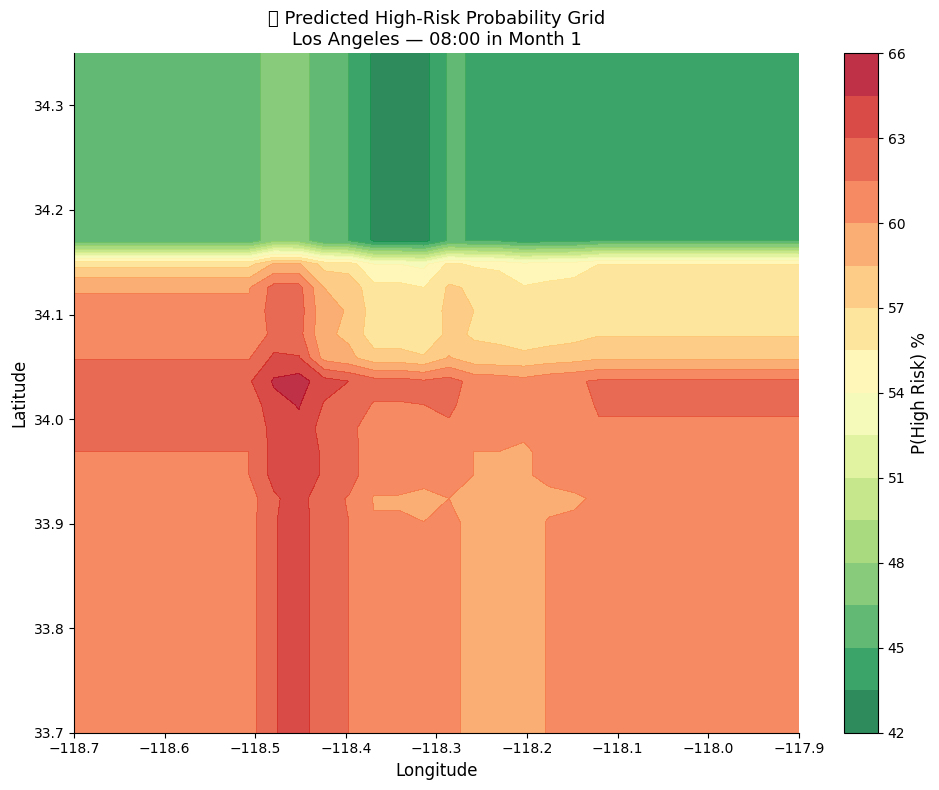

In [21]:
# ── Plot predicted risk grid ──────────────────────────────────────────────────
pivot = grid_df.pivot(index='lat', columns='lon', values='high_prob')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.contourf(
    pivot.columns, pivot.index, pivot.values,
    levels=20, cmap='RdYlGn_r', alpha=0.85
)
plt.colorbar(im, ax=ax, label='P(High Risk) %')
ax.set_title(f'🗺 Predicted High-Risk Probability Grid\n'
             f'{GRID_CITY} — {GRID_HOUR:02d}:00 in Month {GRID_MONTH}',
             fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---
## 10. Save Model Artifacts

In [22]:
# ── Save everything Django will need ─────────────────────────────────────────

# 1. Random Forest model
joblib.dump(rf_model, MODEL_DIR + 'rf_model.pkl', compress=3)

# 2. Label encoder
joblib.dump(le, MODEL_DIR + 'label_encoder.pkl')

# 3. Feature metadata (column names, category lists)
with open(MODEL_DIR + 'feature_meta.json', 'w') as f:
    json.dump(FEATURE_META, f, indent=2)

# 4. Logistic Regression (fallback / comparison)
joblib.dump(lr_pipeline, MODEL_DIR + 'lr_pipeline.pkl', compress=3)

# 5. Model performance summary
perf = {
    'random_forest': {
        'roc_auc'   : round(rf_auc, 4),
        'f1_macro'  : round(float(f1_score(y_test, rf_preds, average='macro')), 4),
        'accuracy'  : round(float(accuracy_score(y_test, rf_preds)), 4),
    },
    'logistic_regression': {
        'roc_auc'   : round(lr_auc, 4),
        'f1_macro'  : round(float(f1_score(y_test, lr_preds, average='macro')), 4),
        'accuracy'  : round(float(accuracy_score(y_test, lr_preds)), 4),
    }
}
with open(MODEL_DIR + 'model_performance.json', 'w') as f:
    json.dump(perf, f, indent=2)

print('✅ Saved model artifacts:')
for fname in os.listdir(MODEL_DIR):
    size = os.path.getsize(MODEL_DIR + fname) / 1e6
    print(f'   {fname:<30} {size:.1f} MB')

print()
print('🚀 Ready for → Django Dashboard')

✅ Saved model artifacts:
   lr_pipeline.pkl                0.0 MB
   model_performance.json         0.0 MB
   label_encoder.pkl              0.0 MB
   rf_model.pkl                   70.9 MB
   feature_meta.json              0.0 MB

🚀 Ready for → Django Dashboard


In [23]:
# ── Final project status ──────────────────────────────────────────────────────
print('=' * 58)
print('  ✅ NOTEBOOK PIPELINE COMPLETE')
print('=' * 58)
print()
print('  Notebook 01  →  accidents_clean.parquet')
print('  Notebook 02  →  accidents_clustered.parquet')
print('                  hotspot_summary.csv')
print('                  maps/*.html')
print('  Notebook 03  →  models/rf_model.pkl')
print('                  models/label_encoder.pkl')
print('                  models/feature_meta.json')
print()
print('  Next: Django dashboard (Step 8)')
print('        - Map view  → hotspot_summary.csv')
print('        - Insights  → accidents_clean.parquet')
print('        - Risk tool → rf_model.pkl + predict_risk()')
print('=' * 58)

  ✅ NOTEBOOK PIPELINE COMPLETE

  Notebook 01  →  accidents_clean.parquet
  Notebook 02  →  accidents_clustered.parquet
                  hotspot_summary.csv
                  maps/*.html
  Notebook 03  →  models/rf_model.pkl
                  models/label_encoder.pkl
                  models/feature_meta.json

  Next: Django dashboard (Step 8)
        - Map view  → hotspot_summary.csv
        - Insights  → accidents_clean.parquet
        - Risk tool → rf_model.pkl + predict_risk()
